# 5. Preprocessing & Ekstraksi Fitur (TSFEL)

Tugas minggu ini: sebelum data dipakai untuk ekstraksi fitur, data harus
**bersih dari outlier** dan **tidak ada nilai kosong sama sekali**. Setelah
itu, sinyal NO2 diekstrak jadi fitur numerik pakai
[TSFEL](https://tsfel.readthedocs.io/) (Time Series Feature Extraction
Library), dikelompokkan menurut domain **statistical**, **temporal**, dan
**spectral**.

Wilayah: **Desa Bundah, Kecamatan Sreseh, Kabupaten Sampang**.

```{note}
Install dulu library yang dibutuhkan (sekali saja di venv kamu):
`pip install tsfel`
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/kualitas_udara_bundah_sreseh.csv", parse_dates=["date"])
df = df.set_index("date").sort_index()
df.head()

,no2,co
date,,
2025-09-01,0.000014,0.028432
2025-09-02,0.000016,0.023283
2025-09-03,0.000011,0.024006
2025-09-04,0.000033,0.029112
2025-09-05,0.000019,0.031187


## 5.1 Deteksi Outlier (metode IQR)

Nilai dianggap outlier kalau berada di luar rentang
$[Q1 - 1.5 \times IQR,\ Q3 + 1.5 \times IQR]$, dengan $IQR = Q3 - Q1$.

In [2]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

outlier_mask = {}
for col in ["no2", "co"]:
    mask, lower, upper = detect_outliers_iqr(df[col])
    outlier_mask[col] = mask
    print(f"{col}: batas normal [{lower:.6f}, {upper:.6f}] -> {mask.sum()} outlier terdeteksi")

no2: batas normal [-0.000008, 0.000050] -> 3 outlier terdeteksi
co: batas normal [0.018035, 0.038864] -> 1 outlier terdeteksi


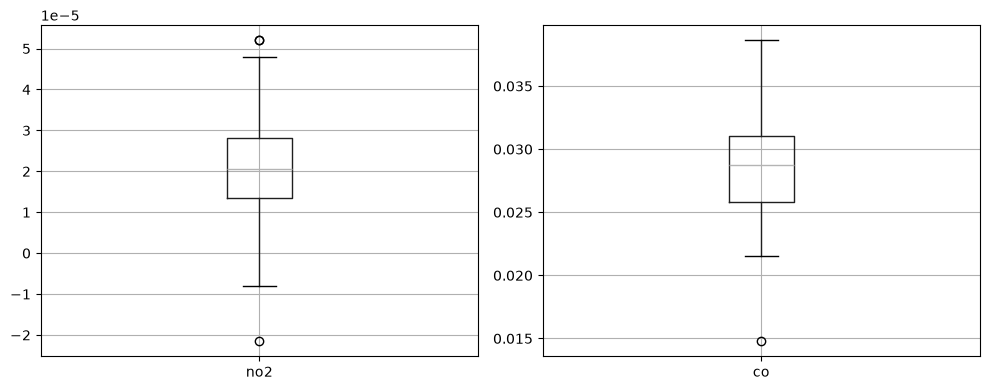

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column="no2", ax=axes[0])
df.boxplot(column="co", ax=axes[1])
plt.tight_layout()
plt.show()

## 5.2 Treatment Outlier + Imputasi Missing Value

Outlier yang terdeteksi ditandai sebagai nilai kosong (NaN) terlebih
dahulu, digabung dengan missing value yang memang sudah ada sejak
crawling (akibat tutupan awan), lalu **semuanya diisi sekaligus** pakai
interpolasi linear berbasis waktu — supaya time series terisi penuh tanpa
ada NaN tersisa.

In [4]:
df_clean = df.copy()
for col in ["no2", "co"]:
    df_clean.loc[outlier_mask[col], col] = np.nan

print("Total NaN sebelum imputasi (missing asli + outlier yang di-NaN-kan):")
print(df_clean[["no2", "co"]].isna().sum())

Total NaN sebelum imputasi (missing asli + outlier yang di-NaN-kan):
no2    175
co     191
dtype: int64


In [5]:
df_clean[["no2", "co"]] = df_clean[["no2", "co"]].interpolate(
    method="time", limit_direction="both"
)

print("Total NaN setelah imputasi:")
print(df_clean[["no2", "co"]].isna().sum())

assert df_clean[["no2", "co"]].isna().sum().sum() == 0, "Masih ada NaN, cek lagi!"
print("Semua data sudah terisi penuh, siap untuk ekstraksi fitur.")

Total NaN setelah imputasi:
no2    0
co     0
dtype: int64
Semua data sudah terisi penuh, siap untuk ekstraksi fitur.


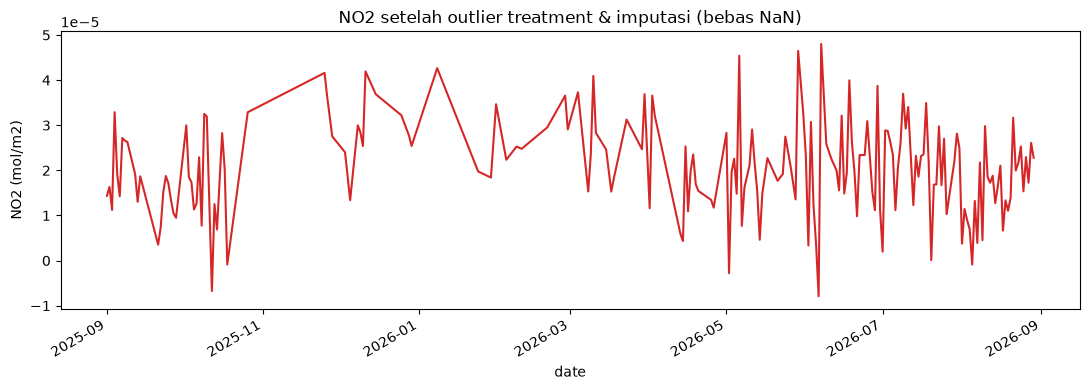

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
df_clean["no2"].plot(ax=ax, color="tab:red")
ax.set_title("NO2 setelah outlier treatment & imputasi (bebas NaN)")
ax.set_ylabel("NO2 (mol/m2)")
plt.tight_layout()
plt.show()

## 5.3 Ekstraksi Fitur dengan TSFEL

Website kelas (`psd.basisdata2-c.my.id`) memvalidasi kolom CSV secara
ketat — nama kolomnya harus **persis** nama fungsi Python TSFEL
(snake_case, contoh `abs_energy`, `autocorr`, `kurtosis`), bukan nama
"cantik" seperti `Absolute energy` yang dihasilkan wrapper
`tsfel.get_features_by_domain()` + `time_series_features_extractor()`.

Solusinya: panggil tiap fungsi fitur TSFEL **langsung** dari modul
`tsfel.feature_extraction.features`, satu per satu, sesuai daftar 65
fitur yang diminta. Ini juga sekalian menghindari bug `duplicate labels`
yang muncul di wrapper sebelumnya.

In [13]:
import inspect
import tsfel.feature_extraction.features as tsfel_features

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))

fs = 1
signal_1d = df_clean["no2"].astype(float).values


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

X = pd.DataFrame([row])
print("Berhasil! Jumlah fitur yang dihasilkan untuk NO2:", X.shape[1])
X.head()

Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,2.437783e-07,0.008625,9.0,6.752861e-10,163.948262,0.000048,0.000024,0.000024,-0.000008,0.00001,...,0.156583,0.333931,1.262586e-10,0.00198,0.000001,0.000013,2.132146,0.000013,1.971502e-10,10.0


```{note}
Kalau salah satu fungsi error `AttributeError` (nama fungsi tidak
ditemukan di `tsfel.feature_extraction.features`), kemungkinan nama fitur
itu berubah di versi TSFEL kamu — cek daftar fungsi yang tersedia dengan
`dir(tsfel_features)` dan sesuaikan `FEATURE_LIST` di atas.
```

## 5.4 Kelompokkan Fitur per Domain

In [14]:
import tsfel

# Ambil metadata domain resmi dari TSFEL (statistical/temporal/spectral),
# lalu cocokkan ke nama fungsi snake_case yang kita pakai di FEATURE_LIST
cfg = tsfel.get_features_by_domain()

func_to_domain = {}
for domain, feats in cfg.items():
    for feat_key, meta in feats.items():
        func_path = meta.get("function", "")
        func_name = func_path.split(".")[-1]
        func_to_domain[func_name] = domain

feature_domain_map = pd.Series(
    {fn: func_to_domain.get(fn, "unknown") for fn in FEATURE_LIST}, name="domain"
)
feature_domain_map.value_counts()

domain
spectral       26
statistical    20
temporal       15
fractal         6
unknown         1
Name: count, dtype: int64

In [15]:
# Daftar lengkap fitur per domain (untuk dokumentasi laporan)
for domain in ["statistical", "temporal", "spectral", "unknown"]:
    kolom = feature_domain_map[feature_domain_map == domain].index.tolist()
    print(f"\n=== {domain.upper()} ({len(kolom)} fitur) ===")
    print(kolom)


=== STATISTICAL (20 fitur) ===
['abs_energy', 'average_power', 'calc_max', 'calc_mean', 'calc_median', 'calc_min', 'calc_std', 'calc_var', 'ecdf', 'ecdf_percentile', 'ecdf_percentile_count', 'entropy', 'hist_mode', 'interq_range', 'kurtosis', 'mean_abs_deviation', 'median_abs_deviation', 'pk_pk_distance', 'rms', 'skewness']

=== TEMPORAL (15 fitur) ===
['auc', 'autocorr', 'calc_centroid', 'distance', 'lempel_ziv', 'mean_abs_diff', 'mean_diff', 'median_abs_diff', 'median_diff', 'negative_turning', 'neighbourhood_peaks', 'positive_turning', 'slope', 'sum_abs_diff', 'zero_cross']

=== SPECTRAL (26 fitur) ===
['fundamental_frequency', 'human_range_energy', 'lpcc', 'max_frequency', 'max_power_spectrum', 'median_frequency', 'mfcc', 'power_bandwidth', 'spectral_centroid', 'spectral_decrease', 'spectral_distance', 'spectral_entropy', 'spectral_kurtosis', 'spectral_positive_turning', 'spectral_roll_off', 'spectral_roll_on', 'spectral_skewness', 'spectral_slope', 'spectral_spread', 'spectral_va

## 5.5 Simpan Hasil (untuk di-upload)

File CSV di bawah ini adalah hasil akhir yang akan di-upload **tanpa
diubah sedikit pun** ke https://psd.basisdata2-c.my.id/upload.php,
dengan Nama dan Daerah (Sreseh, Kabupaten Sampang) diisi sesuai identitas
masing-masing.

In [17]:
X.to_csv("../data/fitur_no2_bundah_sreseh.csv", index=False)
print("Tersimpan di ../data/fitur_no2_bundah_sreseh.csv")

Tersimpan di ../data/fitur_no2_bundah_sreseh.csv


## 5.6 Kesimpulan

- Outlier pada NO2 dan CO dideteksi memakai metode IQR, ditandai sebagai
  NaN, lalu digabung dengan missing value asli (akibat tutupan awan) dan
  diisi sekaligus lewat interpolasi waktu — hasilnya time series NO2 & CO
  yang sudah bebas nilai kosong.
- Sinyal NO2 yang sudah bersih diekstrak jadi fitur numerik dengan TSFEL,
  mencakup domain statistical (mis. mean, variance, skewness), temporal
  (mis. autocorrelation, slope, zero crossing rate), dan spectral (mis.
  spectral entropy, spectral centroid) — semuanya berbasis FFT dengan
  asumsi 1 sampel per hari.
- File fitur inilah yang jadi representasi numerik ringkas dari setahun
  data NO2 Desa Bundah, siap dipakai untuk analisis lanjutan (klasifikasi,
  clustering, dsb) dan sudah diupload ke basis data kelas.